In [2]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
from datetime import datetime
import time
import re
import matplotlib.pyplot as plt
import io

## Data Scraping

### Data Scraping

In [3]:
def get_url(url):
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/111.0.0.0 Safari/537.36'}
    r=requests.get(url, headers=headers)
    return r

In [4]:
def get_year_stat_list():
    url='http://www.pbc.gov.cn/diaochatongjisi/116219/116319/index.html'
    r=get_url(url)
    soup=BeautifulSoup(r.content, 'html.parser')
    domain='http://www.pbc.gov.cn'
    year_stat_list={re.search('[0-9]{4}', item.string).group(0) :domain+item.a.get('href') 
                    for item in soup.find_all('div', {'class': 'wengao2'})}
    return year_stat_list

In [5]:
def get_stat_list(year_url):
    r=get_url(year_url)
    soup=BeautifulSoup(r.content, 'html.parser')
    domain='http://www.pbc.gov.cn'
    stat_list={item.string :domain+item.get('href') 
                        for item in soup.find_all('a', {'class': 'lan14cu'})}
    return stat_list

def get_stat_list_before_2007(year_url):
    r=get_url(year_url)
    soup=BeautifulSoup(r.content, 'html.parser')
    # domain='http://www.pbc.gov.cn'
    # stat_list={item.parent.string :item.get('href') 
    #                     for item in soup.find_all('a', {'class': 'lan14cu'})}
    stat_list={element.parent.get_text():
               element.parent.find('a', {'title': True}).get('href') 
               for element in soup.find_all('a', {'class': 'lan14cu'})}
    return stat_list

In [6]:
def get_file_list(indicator, stat_list):
    ind_list={'Money Supply': 'Money and Banking Statistics', 'Balance Sheet': 'Money and Banking Statistics', 'Official reserve assets': 'Money and Banking Statistics'}
    key=[key for key in stat_list.keys() if ind_list.get(indicator) in key][0]
    url=stat_list.get(key)
    r=get_url(url)
    soup=BeautifulSoup(r.content, 'html.parser')
    domain='http://www.pbc.gov.cn'
    # file_list={re.sub(r'\s+', ' ', item.find('div', {'class': 'titp20'}).text.strip()): 
    #         domain+item.find('a', {'href': re.compile('xls')}).get('href')
    #         for item in soup.find_all('table', {'class': 'a2015'})}
    file_list={}
    for item in soup.find_all('table', {'class': 'a2015'}):
        if item.find('div', {'class': 'titp20'}):
            key=re.sub(r'\s+', ' ', item.find('div', {'class': 'titp20'}).text.strip())
        else:
            key=None
        
        if item.find('a', {'href': re.compile('xls')}):
            url=domain+item.find('a', {'href': re.compile('xls')}).get('href')
        else:
            url=None
        
        if key:
            file_list[key]=url

    return file_list

def get_file_list_before_2014(indicator, stat_list):
    ind_list={'Money Supply': 'Money and Banking Statistics', 'Balance Sheet': 'Money and Banking Statistics', 'Official reserve assets': 'Money and Banking Statistics'}
    key=[key for key in stat_list.keys() if ind_list.get(indicator) in key][0]
    url=stat_list.get(key)
    r=get_url(url)
    soup=BeautifulSoup(r.content, 'html.parser')
#     domain='http://www.pbc.gov.cn'
    file_list={re.sub(r'\s+', ' ', element.parent.get_text().strip()): 
              element.get('href') for element in soup.find_all('a', {'title': True})}

    return file_list


In [7]:
def format_money_supply(df):
    data_header = ['Item', 'M2', 'M1', 'M0']
    mask = df.astype(str).apply(lambda x: x.str.contains('|'.join(data_header), case=False, na=False)).any(axis=1)
    filtered_df = df[mask]
    filtered_df=pd.DataFrame(filtered_df.apply(lambda x: x.dropna().tolist(), axis=1).tolist()).T
    filtered_df=filtered_df.set_index(0)
    filtered_df.columns=filtered_df.iloc[0].str.extract('（(.*?)）$')[0]
    filtered_df=filtered_df[[col for col in filtered_df.columns if not pd.isna(col)]]
    filtered_df=filtered_df.drop('项目 Item', axis=0)
    filtered_df=filtered_df.dropna()
    filtered_df.index=filtered_df.index.str.replace(r'\.1$', '.10', regex=True)
    filtered_df.index=pd.to_datetime(filtered_df.index.str.strip(), format='%Y.%m')
    filtered_df = filtered_df.map(lambda x: x.strip() if isinstance(x, str) else x)
    filtered_df=filtered_df.apply(pd.to_numeric, errors='coerce')
    return filtered_df

In [8]:
def format_reserve(df_raw):
    # 2. Extract the Date row (Index 2) and Unit row (Index 4 contains English units)
    # We fill the NaNs in the date row so '2025.01' covers both USD and SDR columns
    date_row = df_raw.iloc[2].fillna(method='ffill')
    unit_row = df_raw.iloc[4].fillna('')

    # 3. Create dynamic column names by combining Date and Unit
    new_columns = []
    for date, unit in zip(date_row, unit_row):
        date_str = str(date).strip()
        unit_str = str(unit).strip()
        
        if "Item" in date_str:
            new_columns.append("Item")
        elif date_str and unit_str:
            new_columns.append(f"{date_str} ({unit_str})")
        else:
            new_columns.append(f"Unnamed_{len(new_columns)}")

    # 4. Apply headers and clean the data rows
    df = df_raw.copy()
    df.columns = new_columns

    # Filter: Keep rows that start with a number (1., 2., etc.) or are the 'Total' row
    # This dynamically ignores the English sub-header rows and the footer notes
    df_clean = df[df['Item'].str.contains(r'^\d\.|合计|Total', na=False, regex=True)].copy()

    # Clean up whitespace in the Item column
    df_clean['Item'] = df_clean['Item'].str.replace(r'\xa0', ' ', regex=True).str.replace(r'[0-9\.]', '', regex=True).str.strip()
    df_clean=df_clean.set_index('Item')

    # 5. Final Display
    # Drop columns that weren't properly named (trailing empty columns)
    df_clean = df_clean.loc[:, ~df_clean.columns.str.contains('Unnamed')].T
    df_clean=df_clean.reset_index()


    df_clean = df_clean.assign(
        Date = lambda df: pd.to_datetime(df['index'].str.extract(r'([0-9]{4}\.[0-9]{2})', expand=False), format=r'%Y.%m'),
        unit= lambda df: df['index'].str.extract(r'\(([0-9A-Za-z\s]+)\)',   expand=False)
    )
    df_clean=df_clean.drop(['index', 'Total'], axis=1)
    return df_clean

In [9]:
def get_stat_df(indicator, file_list):
    key=[key for key in file_list.keys() if indicator in key][0]
    url=file_list.get(key)
    r=get_url(url)
    df=pd.read_excel(io.BytesIO(r.content), dtype=str)
    return df

def get_stat_df_before_2014(indicator, file_list):
    key=[key for key in file_list.keys() if indicator in key][0]
    url=file_list.get(key)
    r=get_url(url)
    df=pd.read_html(io.BytesIO(r.content))[0]
    return df

In [10]:
def get_money_supply_df(year, year_stat_list):
    # try:
        url=year_stat_list[str(year)]
        stat_list=get_stat_list(url)
        indicator='Money Supply'
        if int(year)<=2007:
             stat_list=get_stat_list_before_2007(url)
             df=get_stat_df_before_2014(indicator, stat_list)
        elif int(year)<=2014:
            stat_list=get_stat_list(url)
            file_list=get_file_list_before_2014(indicator, stat_list)
            df=get_stat_df_before_2014(indicator, file_list)
        else:
            stat_list=get_stat_list(url)
            file_list=get_file_list(indicator, stat_list)
            df=get_stat_df(indicator, file_list)
        df=df.iloc[:13]
        df=format_money_supply(df)
        time.sleep(2)
        return df
    # except:
    #     print(year)

In [11]:
def build_hierarchy_list(lines):
    result = []
    stack = []  # Stores tuples of (indent_level, current_path)

    for line in lines:
        if line.strip() == '':
            result.append('')

        stripped = line.lstrip()
        if not stripped: 
            continue
        
        # Calculate leading spaces
        indent = len(line) - len(stripped)
        
        # Pop from stack if current indent is less than or equal to previous levels
        while stack and stack[-1][0] >= indent:
            stack.pop()
        
        # Determine the full hierarchical path
        if not stack:
            path = stripped
        else:
            path = f"{stack[-1][1]}_{stripped}"
            
        result.append(path)
        stack.append((indent, path))
        
    return result

In [12]:
def format_balance_sheet_df (df):
    mask = df.apply(lambda x: x.astype(str).str.contains('总负债', na=False)).any(axis=1)
    end_row_index = df.index[mask].tolist()[0]
    df=df.iloc[:end_row_index+1]
    df=df.dropna(how='all').reset_index(drop=True)
    df.columns=df[df.astype(str).apply(lambda x: x.str.contains('Item', case=False, na=False)).any(axis=1)].values[0]
    df=df.apply(lambda col: col.replace(r'^\s+$', None, regex=True))
    df = df.dropna(subset=[df.columns[1]])
    df=df[[col for col in df.columns if not pd.isna(col)]]
    df.columns=[re.sub(r'\xa0+|\s+', '', col) for col in df.columns]
    pattern = r'[^\u4e00-\u9fa50-9_\(\)]+'
    item_col_name=[col for col in df.columns if re.search(r'项目', col)][0]
    df['项目_processed']=build_hierarchy_list(df[item_col_name])
    df=df.drop(item_col_name, axis=1)
    df['项目_processed'] = df['项目_processed'].str.replace(pattern, '', regex=True)
    df=df.set_index(df['项目_processed'], drop=True)
    df=df[[col for col in df.columns if re.search(r'[0-9]{4}\.[0-9]{1,2}', col)]]
    df=df.T
    excluded_col=['货币当局资产负债表', 'BalanceSheetOfMonetaryAuthority', '报表项目', '', '项目']
    df=df[[col for col in df.columns if col not in excluded_col]]
    df.index=df.index.str.replace(r'\.1$', r'.10', regex=True)
    df.index=pd.to_datetime(df.index, format='%Y.%m')

    return df

In [13]:
def get_balance_sheet_df(year, year_stat_list):

    try:
        url=year_stat_list[str(year)]
        indicator='Balance Sheet'
        # stat_list
        if int(year)<=2007:
            stat_list=get_stat_list_before_2007(url)
            df=get_stat_df_before_2014(indicator, stat_list)
        elif int(year)<=2014:
            stat_list=get_stat_list(url)
            file_list=get_file_list_before_2014(indicator, stat_list)
            df=get_stat_df_before_2014(indicator, file_list)
        else:
            stat_list=get_stat_list(url)
            file_list=get_file_list(indicator, stat_list)
            df=get_stat_df(indicator, file_list)
        df=format_balance_sheet_df(df)
        time.sleep(10)
        return df
    except:
        print(year)

In [14]:
def get_reserve_df(year, year_stat_list):
    # try:
        url=year_stat_list[str(year)]
        stat_list=get_stat_list(url)
        indicator='Official reserve assets'
        if year<=2007:
             stat_list=get_stat_list_before_2007(url)
             df=get_stat_df_before_2014(indicator, stat_list)
        elif year<=2014:
            stat_list=get_stat_list(url)
            file_list=get_file_list_before_2014(indicator, stat_list)
            df=get_stat_df_before_2014(indicator, file_list)
        else:
            stat_list=get_stat_list(url)
            file_list=get_file_list(indicator, stat_list)
            df=get_stat_df(indicator, file_list)
        df=df.iloc[:13]
        df=format_reserve(df)
        time.sleep(2)
        return df
    # except:
    #     print(year)

### Common variables

In [ ]:
year_stat_list=get_year_stat_list()

### PBOC Balance Sheet

In [ ]:
# years=range(2006, 2026)
# year=list(years)[-7]
# dfs=[get_balance_sheet_df(year, year_stat_list) for year in years]
# df=pd.concat(dfs)
year=2026
df=get_balance_sheet_df(year, year_stat_list)
df['updated_at'] = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
df.to_csv('PBOC_Balance_Sheet.csv')

### PBOC Money Supply

In [ ]:
# year_stat_list=get_year_stat_list()
# years=range(2026, 2027)
# dfs=[get_money_supply_df(year, year_stat_list) for year in years]
# df=pd.concat(dfs)
year='2026'
df=get_money_supply_df(year, year_stat_list)
df['updated_at'] = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
df.to_csv('PBOC_Money_Supply.csv')

### PBOC Reserve (broken)

In [ ]:
# year_stat_list=get_year_stat_list()
# years=range(2006, 2026)
# dfs=[get_reserve_df(year, year_stat_list) for year in years]
# df=pd.concat(dfs)
year=2026
df=get_reserve_df(year, year_stat_list)

df['updated_at'] = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
df
# df.to_csv('PBOC_Reserve.csv')

## Ploting

### Read Result

In [2]:
df=pd.concat([pd.read_csv('PBOC_Balance_Sheet.csv'), pd.read_csv('PBOC_Money_Supply.csv')], axis=1)
df=df.set_index('Date')
df.columns

Index(['货币当局资产负债表', 'BalanceSheetOfMonetaryAuthority', '报表项目Items',
       '国外资产ForeignAssets', '外汇ForeignExchange', '货币黄金MonetaryGold',
       '其他国外资产OtherForeignAssets', '对政府债权ClaimsOnGovernment',
       '其中：中央政府OfWhich:CentralGovernment',
       '对其他存款性公司债权ClaimsOnOtherDepositoryCorporations',
       '对其他金融性公司债权ClaimsOnOtherFinancialCorporations',
       '对非金融性公司债权ClaimsOnNon-FinancialCorporations', '其他资产OtherAssets',
       '总资产TotalAssets', '储备货币ReserveMoney', '货币发行CurrencyIssue',
       '金融性公司存款DepositOfFinancialCorporations',
       '其他存款性公司OtherDepositoryCorporations',
       '其他金融性公司OtherFinancialCorporations',
       '非金融性公司存款DepositsOfNon-FinancialCorporations', '活期存款DemandDeposits',
       '发行债券BondIssue', '国外负债ForeignLiabilities', '政府存款DepositsOfGovernment',
       '自有资金OwnCapital', '其他负债OtherLiabilities', '总负债TotalLiabilities',
       '金融性公司存款DepositsOfFinancialCorporations',
       '不计入储备货币的金融性公司存款DepositsOfFinancialCorporationsExcludedFromReserveMoney',
       '注：自2008年

### Ploting

In [3]:
from matplotlib.colors import TABLEAU_COLORS

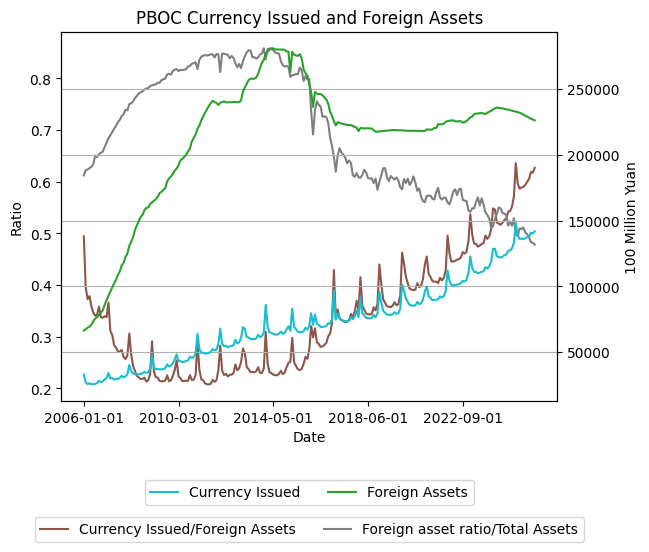

In [6]:
import matplotlib.dates as mdates
ax=(df['货币发行CurrencyIssue'].astype(float)/df['国外资产ForeignAssets'].astype(float)).sort_index().plot(color=TABLEAU_COLORS['tab:brown'],
    title='PBOC Currency Issued and Foreign Assets', ylabel='Ratio', label='Currency Issued/Foreign Assets')
ax=(df['国外资产ForeignAssets'].astype(float)/df['总资产TotalAssets'].astype(float)).sort_index().plot(color=TABLEAU_COLORS['tab:gray'],
    ylabel='Ratio', label='Foreign asset ratio/Total Assets')
ay=ax.twinx()
df['货币发行CurrencyIssue'].astype(float).sort_index().plot(ax=ay, color=TABLEAU_COLORS['tab:cyan'], label='Currency Issued', ylabel='100 Million Yuan')
df['国外资产ForeignAssets'].astype(float).sort_index().plot(ax=ay, color=TABLEAU_COLORS['tab:green'], label='Foreign Assets')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.4), ncol=2)
ay.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=2)
# ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3)) # Month intervals
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # date formatting
plt.grid()

[]

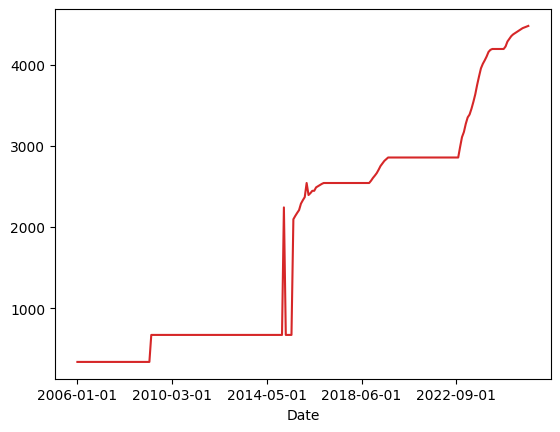

In [10]:
ax=df['货币黄金MonetaryGold'].astype(float).sort_index().plot(color=TABLEAU_COLORS['tab:red'], label='Monetary Gold')
plt.plot()

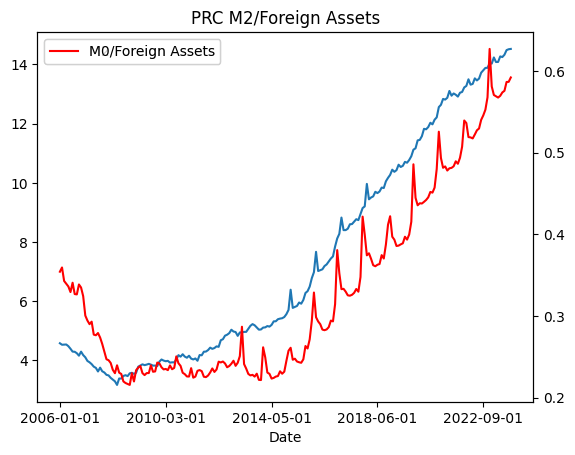

In [30]:
ax=(df['M2']/df['国外资产ForeignAssets'].astype(float)).sort_index().plot(title='PRC M2/Foreign Assets', label='M2/Foreign Assets')
plt.legend()
ay=ax.twinx()
(df['M0']/df['国外资产ForeignAssets'].astype(float)).sort_index().plot(ax=ay, label='M0/Foreign Assets', color='red')
plt.legend()

<Axes: title={'center': 'PRC M2/M0'}, xlabel='Date'>

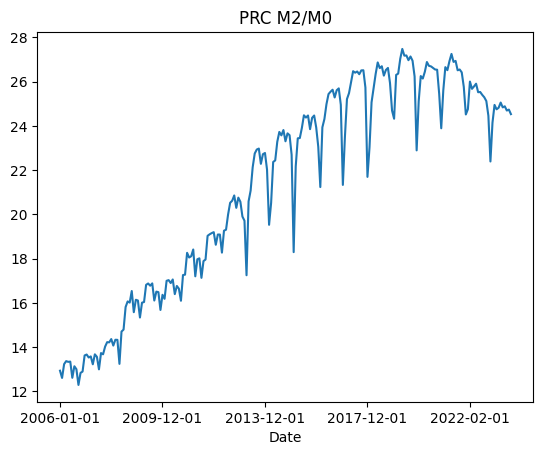

In [31]:
(df['M2']/df['M0']).plot(title='PRC M2/M0')
# plt.grid()

C:\Users\tonyfong\AppData\Local\Temp\ipykernel_2788\16335526.py:1: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ax=df['M2'].pct_change().plot()
C:\Users\tonyfong\AppData\Local\Temp\ipykernel_2788\16335526.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ax.axhline(y=df['M2'].pct_change().mean(), color='red', linestyle='--')


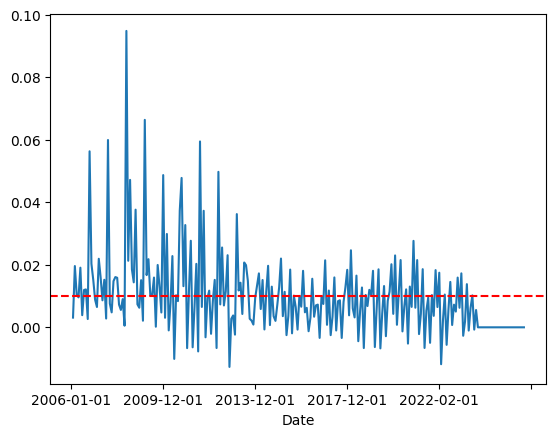

In [32]:
ax=df['M2'].pct_change().plot()
ax.axhline(y=df['M2'].pct_change().mean(), color='red', linestyle='--')

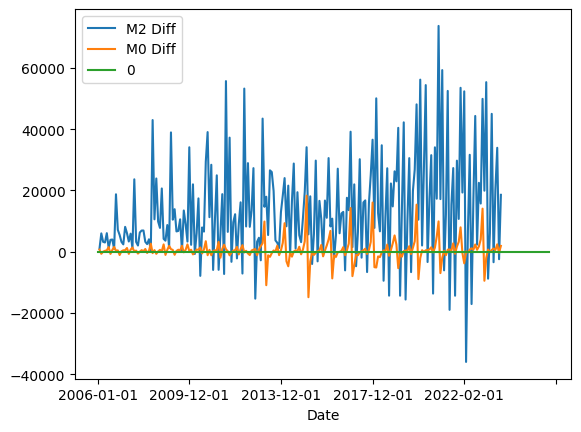

In [33]:
df['0'] = 0
df['M2_diff']=df['M2'].diff()
ax = df['M2_diff'].plot(label='M2 Diff')
df['M0'].diff().plot(ax=ax, label='M0 Diff')
# Add the second plot to the *same* axes object by calling the .plot() method on `ax`
df['0'].plot(ax=ax)

# Optional: Add a legend to differentiate the lines
ax.legend()


In [38]:
df

,货币当局资产负债表,BalanceSheetOfMonetaryAuthority,报表项目Items,国外资产ForeignAssets,外汇ForeignExchange,货币黄金MonetaryGold,其他国外资产OtherForeignAssets,对政府债权ClaimsOnGovernment,其中：中央政府OfWhich:CentralGovernment,对其他存款性公司债权ClaimsOnOtherDepositoryCorporations,...,2.自2011年1月起，境外金融机构在人民银行存款数据计入国外负债项目，不再计入其他存款性公司存款。,项目Item,不计入储备货币的金融性公司存款DepositsOfFinancialCorporationsExcludedFromReserveMone,不计入储备货币的金融性公司存款DepositsOfFinancialCorporationsExcludedFromR,非金融机构存款DepositsOfNon-FinancialInstitutions,不计入储备货币的金融性公司存款DepositsOfFinancialCorporationsExcludedFromReserveM,0,M2,M1,M0
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-01,货币当局资产负债表,Balance Sheet of Monetary Authority,2006.01,66269.40,65062.06,337.24,870.10,2892.43,2892.43,9080.89,...,NaN,NaN,NaN,NaN,NaN,NaN,2006-01-01,303571.65,104357.08,23472.03
2006-02-01,货币当局资产负债表,Balance Sheet of Monetary Authority,2006.02,67214.75,65999.54,337.24,877.97,2891.88,2891.88,7871.79,...,NaN,NaN,NaN,NaN,NaN,NaN,2006-02-01,304516.27,106737.08,24155.73
2006-03-01,货币当局资产负债表,Balance Sheet of Monetary Authority,2006.03,68440.01,67230.32,337.24,872.45,2891.88,2891.88,7808.61,...,NaN,NaN,NaN,NaN,NaN,NaN,2006-03-01,310490.65,106389.11,23465.32
2006-04-01,货币当局资产负债表,Balance Sheet of Monetary Authority,2006.04,69110.69,67896.47,337.24,876.98,2891.88,2891.88,7125.85,...,NaN,NaN,NaN,NaN,NaN,NaN,2006-04-01,313702.34,109219.22,23469.08
2006-05-01,货币当局资产负债表,Balance Sheet of Monetary Authority,2006.05,70662.90,69430.23,337.24,895.43,2891.88,2891.88,6959.06,...,NaN,NaN,NaN,NaN,NaN,NaN,2006-05-01,316709.81,112342.36,23752.59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,NaN,NaN,NaN,228117.35,214382.04,4449.23,9286.08,22481.37,22481.37,186383.07,...,NaN,2025.08,NaN,NaN,25010.29,NaN,NaN,NaN,NaN,NaN
2025-09-01,NaN,NaN,NaN,227468.32,213680.60,4457.98,9329.74,22206.02,22206.02,195356.99,...,NaN,2025.09,NaN,NaN,25461.11,NaN,NaN,NaN,NaN,NaN
2025-10-01,NaN,NaN,NaN,226776.72,213003.00,4467.16,9306.56,21437.88,21437.88,195503.22,...,NaN,2025.10,NaN,NaN,25543.89,NaN,NaN,NaN,NaN,NaN
